In [1]:
import numpy as np
import pandas as pd 
import os
os.chdir('..')  # Go up to project root
import matplotlib.pyplot as plt
from scipy import stats
import pyarrow.parquet as pq
import seaborn as sns
for dirname, _, filenames in os.walk('./kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

./kaggle/input/broad-peak.csv
./kaggle/input/lhotse.csv
./kaggle/input/kangchenjunga.csv
./kaggle/input/.DS_Store
./kaggle/input/cho-oyu.csv
./kaggle/input/manaslu.csv
./kaggle/input/dhaulagiri-I.csv
./kaggle/input/EVER.parquet
./kaggle/input/everest.csv
./kaggle/input/k2.csv
./kaggle/input/nanga-parbat.csv
./kaggle/input/gasherbrum-II.csv
./kaggle/input/shishapangma.csv
./kaggle/input/gasherbrum-I.csv
./kaggle/input/annapurna-I.csv
./kaggle/input/deaths_by_year_mountain.csv
./kaggle/input/makalu.csv


In [3]:
everest = pd.read_csv('./kaggle/input/everest.csv')
everesttemps = pd.read_parquet('./kaggle/input/EVER.parquet')

In [4]:
everesttemps.head()

,peakid,date,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,wind_speed_100m,wind_direction_100m,weather_code,surface_pressure,et0_fao_evapotranspiration,vapour_pressure_deficit,snow_depth,shortwave_radiation,direct_radiation,diffuse_radiation
0,EVER,1980-01-01 00:00:00+00:00,-42.257999,65.533333,0.1,0.0,0.07,10.495713,247.833603,71,320.562103,0.000000,0.005050,26.72,0.0,0.0,0.0
1,EVER,1980-01-01 01:00:00+00:00,-43.307999,65.239151,0.1,0.0,0.07,9.904906,250.906403,71,319.143005,0.000000,0.004547,26.72,0.0,0.0,0.0
2,EVER,1980-01-01 02:00:00+00:00,-43.407997,65.210953,0.0,0.0,0.07,9.565437,250.201035,71,319.249481,0.001487,0.004501,26.72,69.0,43.0,26.0
3,EVER,1980-01-01 03:00:00+00:00,-42.858002,64.642563,0.0,0.0,0.07,8.699793,245.556061,71,320.421326,0.009074,0.004856,26.72,290.0,218.0,72.0
4,EVER,1980-01-01 04:00:00+00:00,-40.757999,60.427090,0.0,0.0,0.07,9.290511,234.462234,71,323.635406,0.020720,0.006801,26.72,504.0,410.0,94.0


In [5]:
# First, convert date to just date (no time)
everesttemps['date_only'] = pd.to_datetime(everesttemps['date']).dt.date

# Group by date and aggregate
# Use mode for categorical/weather columns, mean for numerical measurements
daily_everest = everesttemps.groupby('date_only').agg({
    'peakid': lambda x: x.mode()[0] if len(x.mode()) > 0 else x.iloc[0],  # Mode
    'temperature_2m': 'mean',  # Average temperature
    'relative_humidity_2m': 'mean',  # Average humidity
    'precipitation': 'sum',  # Total precipitation
    'rain': 'sum',  # Total rain
    'snowfall': 'sum',  # Total snowfall
    'wind_speed_100m': 'mean',  # Average wind speed
    'wind_direction_100m': lambda x: x.mode()[0] if len(x.mode()) > 0 else x.iloc[0],  # Mode
    'weather_code': lambda x: x.mode()[0] if len(x.mode()) > 0 else x.iloc[0],  # Mode
    'surface_pressure': 'mean',  # Average pressure
    'et0_fao_evapotranspiration': 'sum',  # Total evapotranspiration
    'vapour_pressure_deficit': 'mean',  # Average VPD
    'snow_depth': 'mean',  # Average snow depth
    'shortwave_radiation': 'sum',  # Total radiation
    'direct_radiation': 'sum',  # Total direct radiation
    'diffuse_radiation': 'sum'  # Total diffuse radiation
}).reset_index()

print(f"Original dataset: {len(everesttemps)} rows (hourly)")
print(f"Aggregated dataset: {len(daily_everest)} rows (daily)")
print(daily_everest.head())

Original dataset: 394488 rows (hourly)
Aggregated dataset: 16437 rows (daily)
    date_only peakid  temperature_2m  relative_humidity_2m  precipitation  \
0  1980-01-01   EVER      -41.080914             61.184116            4.2   
1  1980-01-02   EVER      -43.249664             25.218580            2.0   
2  1980-01-03   EVER      -44.057999             11.458504            0.5   
3  1980-01-04   EVER      -42.401749              6.349964            0.0   
4  1980-01-05   EVER      -42.583000              6.322521            0.6   

   rain  snowfall  wind_speed_100m  wind_direction_100m  weather_code  \
0   0.0      3.36        11.182387           234.462234            71   
1   0.0      1.82        12.834381           228.366547            71   
2   0.0      1.68        11.404770           232.431335            71   
3   0.0      1.61        10.690829           236.309906            71   
4   0.0      1.61         9.154526           236.309906            71   

   surface_pressure 

In [6]:
# Convert both to the same datetime format (no .date())
everest['Date'] = pd.to_datetime(everest['Date'])
daily_everest['date_only'] = pd.to_datetime(daily_everest['date_only'])

In [7]:
# Now merge
everest_with_weather = everest.merge(
    daily_everest, 
    left_on='Date', 
    right_on='date_only', 
    how='left'
)

print(f"Original everest: {len(everest)} rows")
print(f"After merge: {len(everest_with_weather)} rows")
print(f"Rows with weather data: {everest_with_weather['temperature_2m'].notna().sum()}")
print("\nSample:")
print(everest_with_weather[['Date', 'Name', 'temperature_2m', 'wind_speed_100m']].head())

Original everest: 310 rows
After merge: 310 rows
Rows with weather data: 263

Sample:
        Date                Name  temperature_2m  wind_speed_100m
0 2022-05-08     Pavel Kostrikin      -28.446335         6.133541
1 2022-04-14  Ngimi Tenji Sherpa      -36.267166        14.201050
2 2021-05-23  Wong Dorchi Sherpa      -25.204666        11.870899
3 2021-05-18  Pemba Tashi Sherpa      -23.902586        15.412021
4 2021-05-12       Abdul Waraich      -29.800501        10.238065


In [8]:
everest_with_weather.head()

,Date,Name,Nationality,Cause of death,"Lat, Lon",Rank,Age,Gender,Location,Location_in_Meters,...,wind_speed_100m,wind_direction_100m,weather_code,surface_pressure,et0_fao_evapotranspiration,vapour_pressure_deficit,snow_depth,shortwave_radiation,direct_radiation,diffuse_radiation
0,2022-05-08,Pavel Kostrikin,Russia,Altitude sickness,"27.9882° N, 86.9254° E",1,55.0,Male,Camp I,6065m,...,6.133541,206.564987,3.0,342.009155,1.155311,0.006906,26.67000,8140.0,2822.0,5318.0
1,2022-04-14,Ngimi Tenji Sherpa,Nepal,Exhaustion,"27.9882° N, 86.9254° E",1,38.0,Male,Camp I,6065m,...,14.201050,224.999893,0.0,331.973602,0.729520,0.009978,26.66000,9289.0,8048.0,1241.0
2,2021-05-23,Wong Dorchi Sherpa,Nepal,Fall into crevasse,"27.9882° N, 86.9254° E",1,40.0,Male,Death Zone,8200m,...,11.870899,206.564987,0.0,346.579712,1.620365,0.028574,26.67250,9814.0,8603.0,1211.0
3,2021-05-18,Pemba Tashi Sherpa,Nepal,Fall into crevasse,"27.9882° N, 86.9254° E",1,54.0,Male,Western Cwm,6200m,...,15.412021,250.016800,3.0,348.179901,1.258416,0.008168,26.66875,7577.0,3392.0,4185.0
4,2021-05-12,Abdul Waraich,Switzerland,Exhaustion,"27.9882° N, 86.9254° E",1,41.0,Male,South Summit,8750m,...,10.238065,229.398788,3.0,338.614716,1.007939,0.007484,26.66625,8519.0,4452.0,4067.0


In [9]:
# 1. Weather Conditions on Death Days vs Normal Days
print("WEATHER ON DEATH DAYS")
print("=" * 80)
print(f"Average temperature on death days: {everest_with_weather['temperature_2m'].mean():.1f}°C")
print(f"Average wind speed on death days: {everest_with_weather['wind_speed_100m'].mean():.1f} m/s")
print(f"Average precipitation on death days: {everest_with_weather['precipitation'].mean():.2f} mm")
print(f"Average snowfall on death days: {everest_with_weather['snowfall'].mean():.1f} cm")

WEATHER ON DEATH DAYS
Average temperature on death days: -25.8°C
Average wind speed on death days: 7.3 m/s
Average precipitation on death days: 2.39 mm
Average snowfall on death days: 1.7 cm


In [11]:
# 2. Weather by Cause of Death
print("\n\nWEATHER CONDITIONS BY CAUSE OF DEATH")
print("=" * 80)
weather_by_cause = everest_with_weather.groupby('Cause of death').agg({
    'temperature_2m': 'mean',
    'wind_speed_100m': 'mean',
    'precipitation': 'mean',
    'snowfall': 'mean',
    'weather_code': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'N/A'
}).round(2)
print(weather_by_cause)



WEATHER CONDITIONS BY CAUSE OF DEATH
                                                    temperature_2m  \
Cause of death                                                       
2014 Mount Everest Avalanche                            -29.250000   
Altitude                                                -31.889999   
Altitude sickness                                       -25.120001   
Avalanche                                               -24.010000   
Base Camp avalanche following the April 2015 Ne...      -31.090000   
Brain hemorrhage                                               NaN   
Cardiac arrest                                          -27.879999   
Cardiac event                                           -24.320000   
Cardiac event during descent                            -27.340000   
Cerebral apoplexy                                       -19.680000   
Cerebral oedema                                         -23.860001   
Cerebral thrombosis                                

In [12]:
# 3. Extreme Weather Deaths
print("\n\nEXTREME WEATHER ANALYSIS")
print("=" * 80)
# Define extreme conditions
extreme_cold = everest_with_weather[everest_with_weather['temperature_2m'] < -40]
extreme_wind = everest_with_weather[everest_with_weather['wind_speed_100m'] > 30]
heavy_precip = everest_with_weather[everest_with_weather['precipitation'] > 5]

print(f"Deaths in extreme cold (<-40°C): {len(extreme_cold)} ({len(extreme_cold)/len(everest_with_weather)*100:.1f}%)")
print(f"Deaths in extreme wind (>30 m/s): {len(extreme_wind)} ({len(extreme_wind)/len(everest_with_weather)*100:.1f}%)")
print(f"Deaths with heavy precipitation (>5mm): {len(heavy_precip)} ({len(heavy_precip)/len(everest_with_weather)*100:.1f}%)")




EXTREME WEATHER ANALYSIS
Deaths in extreme cold (<-40°C): 1 (0.3%)
Deaths in extreme wind (>30 m/s): 0 (0.0%)
Deaths with heavy precipitation (>5mm): 33 (10.6%)


In [13]:
# 4. Weather vs Experience Level
print("\n\nWEATHER BY EXPERIENCE LEVEL")
print("=" * 80)
weather_by_exp = everest_with_weather.groupby('Experience_Level').agg({
    'temperature_2m': 'mean',
    'wind_speed_100m': 'mean',
    'precipitation': 'mean',
    'snowfall': 'mean',
}).round(2)
print(weather_by_exp)



WEATHER BY EXPERIENCE LEVEL
                  temperature_2m  wind_speed_100m  precipitation  snowfall
Experience_Level                                                          
Experienced           -27.370001             6.14           0.71      0.64
Expert                -27.639999             7.30           0.00      0.00
Intermediate          -28.610001             5.92           0.67      0.61
Novice                -30.160000             5.21           1.25      1.14
Sherpa                -26.930000            10.06           1.61      1.12


In [17]:
# Remove the 'm' and convert to numeric
everest_with_weather['Location_in_Meters'] = (
    everest_with_weather['Location_in_Meters']
    .str.replace('m', '', regex=False)
    .astype(float)
)

# 5. Correlation: Weather vs Altitude of Death
print("\n\nCORRELATION: WEATHER VS ALTITUDE")
print("=" * 80)
weather_cols = ['temperature_2m', 'wind_speed_100m', 'precipitation', 'snowfall']
correlations = everest_with_weather[weather_cols + ['Location_in_Meters']].corr()['Location_in_Meters'].drop('Location_in_Meters')
print(correlations.sort_values(ascending=False))



CORRELATION: WEATHER VS ALTITUDE
temperature_2m     0.540309
wind_speed_100m    0.304569
precipitation     -0.248763
snowfall          -0.337779
Name: Location_in_Meters, dtype: float64


In [18]:
# 6. Most Dangerous Weather Combinations
print("\n\nMOST DANGEROUS WEATHER CONDITIONS")
print("=" * 80)
# Create weather severity score
everest_with_weather['weather_severity'] = (
    (everest_with_weather['temperature_2m'] < -35).astype(int) +  # Extreme cold
    (everest_with_weather['wind_speed_100m'] > 25).astype(int) +  # High wind
    (everest_with_weather['precipitation'] > 2).astype(int)        # Precipitation
)
print(everest_with_weather['weather_severity'].value_counts().sort_index())
print(f"\nDeaths with 2+ severe conditions: {(everest_with_weather['weather_severity'] >= 2).sum()}")




MOST DANGEROUS WEATHER CONDITIONS
weather_severity
0    226
1     82
2      2
Name: count, dtype: int64

Deaths with 2+ severe conditions: 2


In [19]:
# 8. Temperature Ranges
print("\n\nTEMPERATURE DISTRIBUTION ON DEATH DAYS")
print("=" * 80)
temp_bins = pd.cut(everest_with_weather['temperature_2m'], 
                   bins=[-60, -45, -40, -35, -30, -25, 0],
                   labels=['< -45°C', '-45 to -40°C', '-40 to -35°C', '-35 to -30°C', '-30 to -25°C', '> -25°C'])
print(temp_bins.value_counts().sort_index())



TEMPERATURE DISTRIBUTION ON DEATH DAYS
temperature_2m
< -45°C           0
-45 to -40°C      1
-40 to -35°C      7
-35 to -30°C     30
-30 to -25°C    105
> -25°C         120
Name: count, dtype: int64


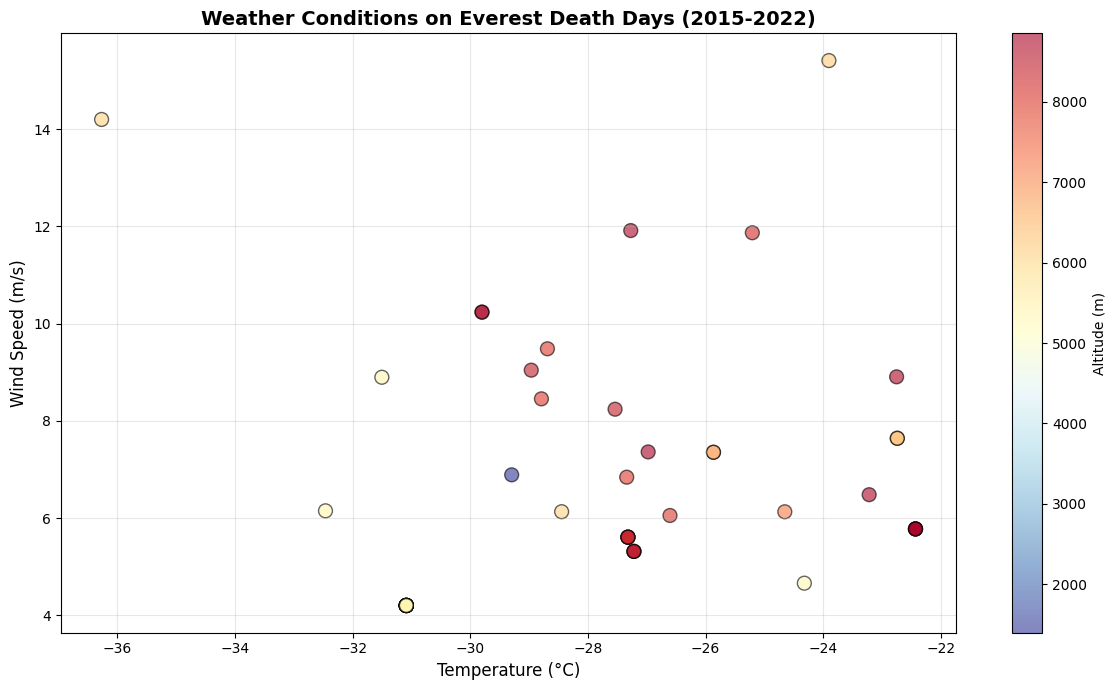

In [22]:
# 1. Temperature vs Wind Speed on Death Days
plt.figure(figsize=(12, 7))
scatter = plt.scatter(everest_with_weather['temperature_2m'], 
                     everest_with_weather['wind_speed_100m'],
                     c=everest_with_weather['Location_in_Meters'],
                     cmap='RdYlBu_r',
                     s=100,
                     alpha=0.6,
                     edgecolors='black')
plt.colorbar(scatter, label='Altitude (m)')
plt.xlabel('Temperature (°C)', fontsize=12)
plt.ylabel('Wind Speed (m/s)', fontsize=12)
plt.title('Weather Conditions on Everest Death Days (2015-2022)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save plot
plt.savefig('images/everest_weather_deaths_scatter.png', dpi=300, bbox_inches='tight')
plt.show()


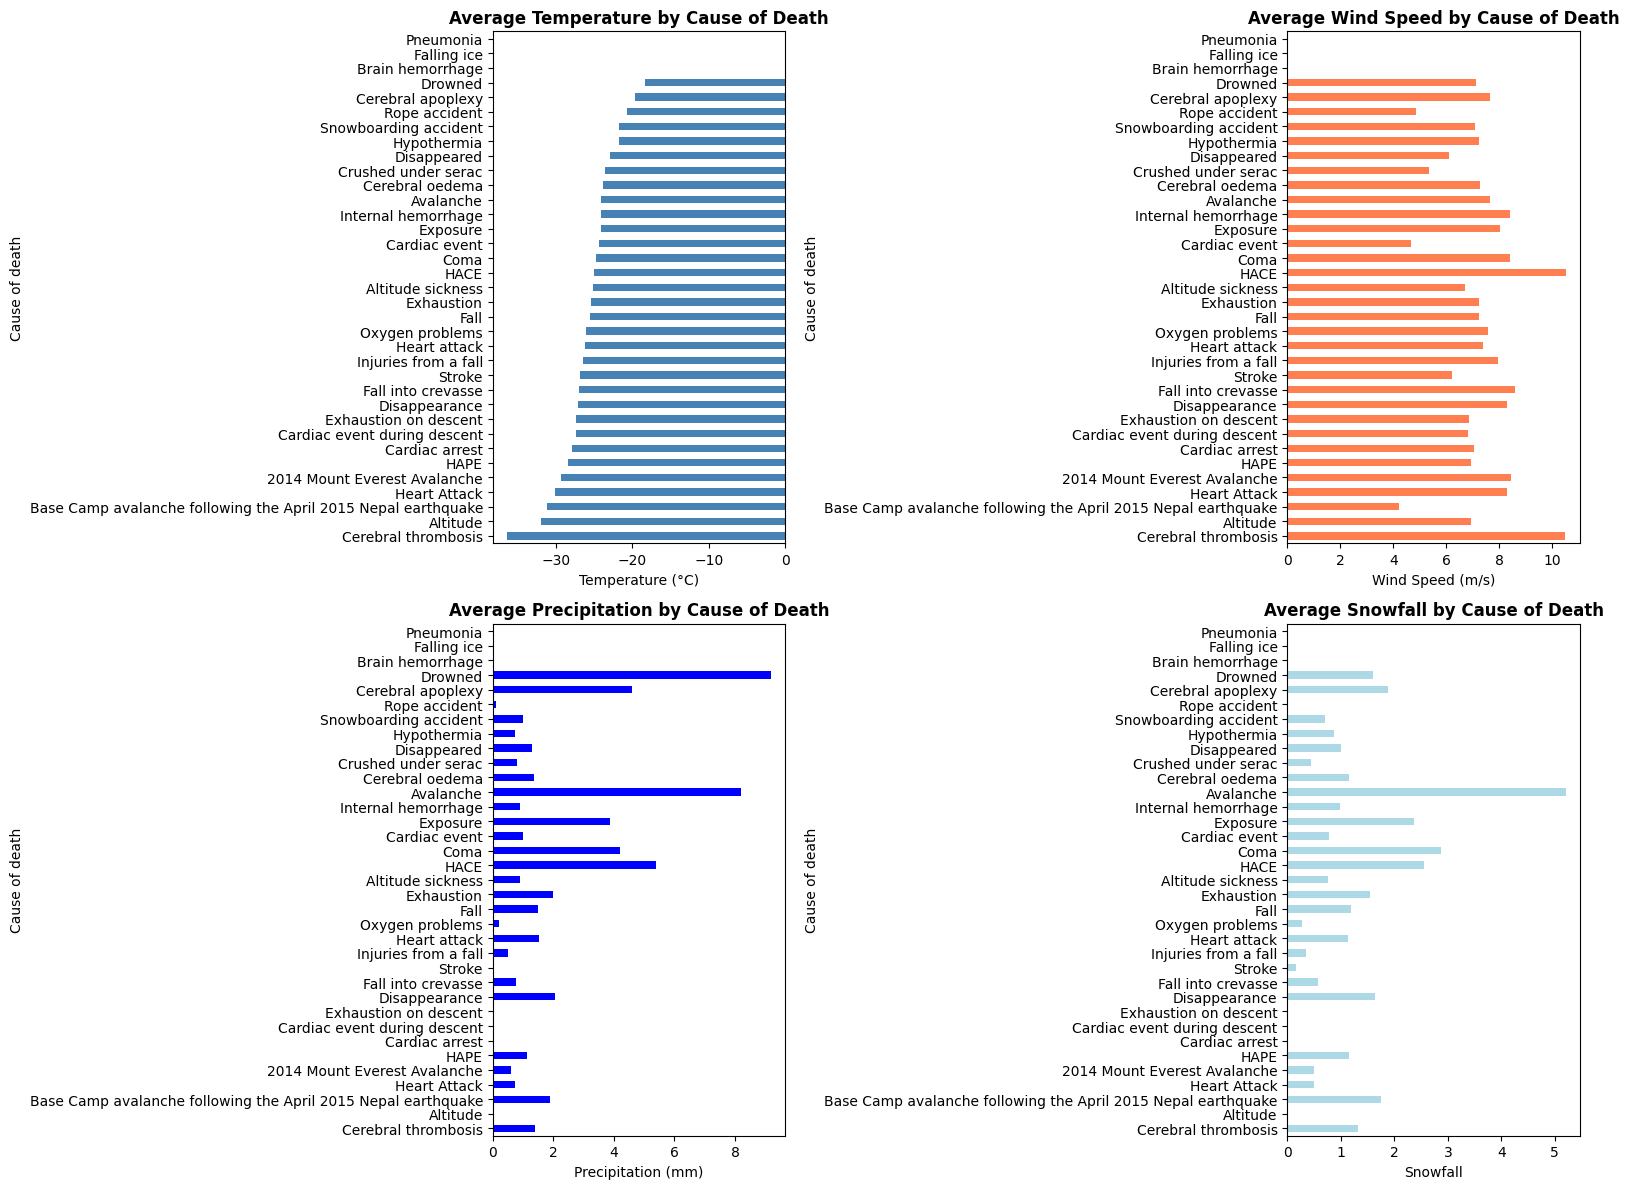

In [24]:
# 2. Weather by Cause of Death
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Temperature by cause
cause_weather = everest_with_weather.groupby('Cause of death').agg({
    'temperature_2m': 'mean',
    'wind_speed_100m': 'mean',
    'precipitation': 'mean',
    'snowfall': 'mean',
}).sort_values('temperature_2m')

cause_weather['temperature_2m'].plot(kind='barh', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Average Temperature by Cause of Death', fontweight='bold')
axes[0,0].set_xlabel('Temperature (°C)')

cause_weather['wind_speed_100m'].plot(kind='barh', ax=axes[0,1], color='coral')
axes[0,1].set_title('Average Wind Speed by Cause of Death', fontweight='bold')
axes[0,1].set_xlabel('Wind Speed (m/s)')

cause_weather['precipitation'].plot(kind='barh', ax=axes[1,0], color='blue')
axes[1,0].set_title('Average Precipitation by Cause of Death', fontweight='bold')
axes[1,0].set_xlabel('Precipitation (mm)')

cause_weather['snowfall'].plot(kind='barh', ax=axes[1,1], color='lightblue')
axes[1,1].set_title('Average Snowfall by Cause of Death', fontweight='bold')
axes[1,1].set_xlabel('Snowfall')

plt.tight_layout()

# Save plot
plt.savefig('images/everest_weather_by_cause.png', dpi=300, bbox_inches='tight')
plt.show()

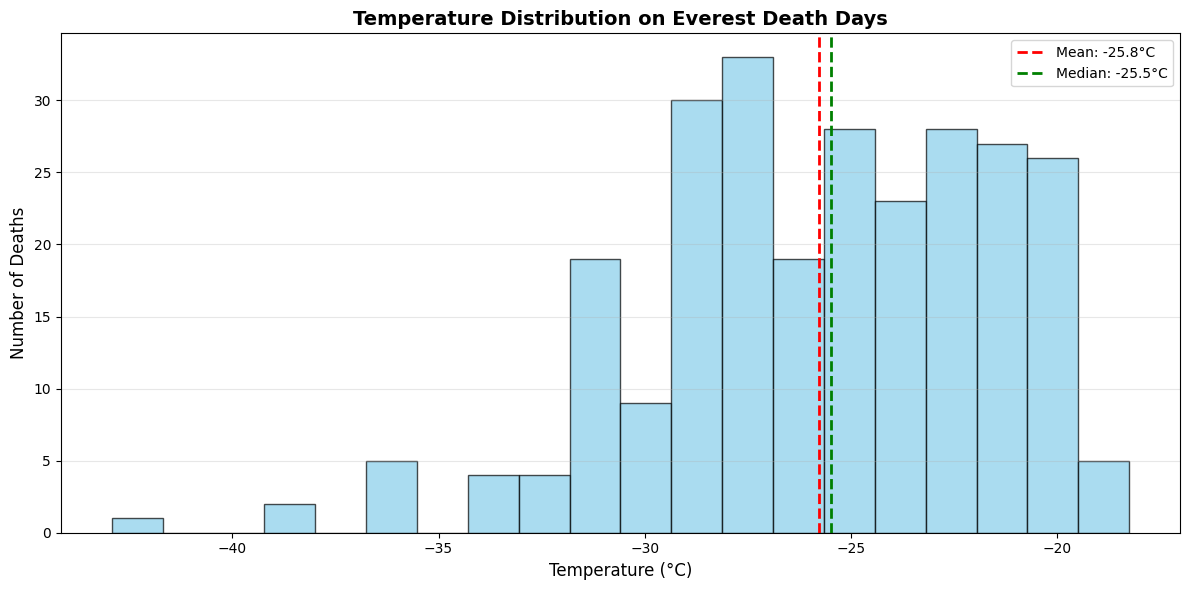

In [25]:
# 3. Temperature Distribution
plt.figure(figsize=(12, 6))
plt.hist(everest_with_weather['temperature_2m'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(everest_with_weather['temperature_2m'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {everest_with_weather["temperature_2m"].mean():.1f}°C')
plt.axvline(everest_with_weather['temperature_2m'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {everest_with_weather["temperature_2m"].median():.1f}°C')
plt.xlabel('Temperature (°C)', fontsize=12)
plt.ylabel('Number of Deaths', fontsize=12)
plt.title('Temperature Distribution on Everest Death Days', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()

# Save plot
plt.savefig('images/everest_temperature_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

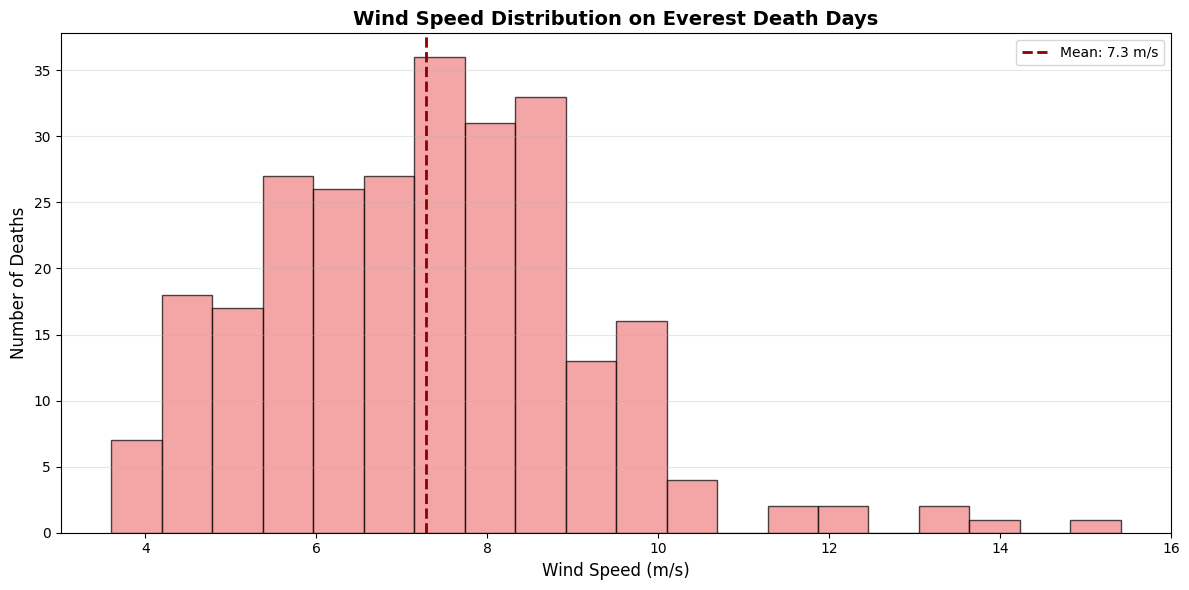

In [26]:
# 4. Wind Speed Distribution
plt.figure(figsize=(12, 6))
plt.hist(everest_with_weather['wind_speed_100m'], bins=20, color='lightcoral', edgecolor='black', alpha=0.7)
plt.axvline(everest_with_weather['wind_speed_100m'].mean(), color='darkred', linestyle='--', linewidth=2, label=f'Mean: {everest_with_weather["wind_speed_100m"].mean():.1f} m/s')
plt.xlabel('Wind Speed (m/s)', fontsize=12)
plt.ylabel('Number of Deaths', fontsize=12)
plt.title('Wind Speed Distribution on Everest Death Days', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()

# Save plot
plt.savefig('images/everest_wind_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

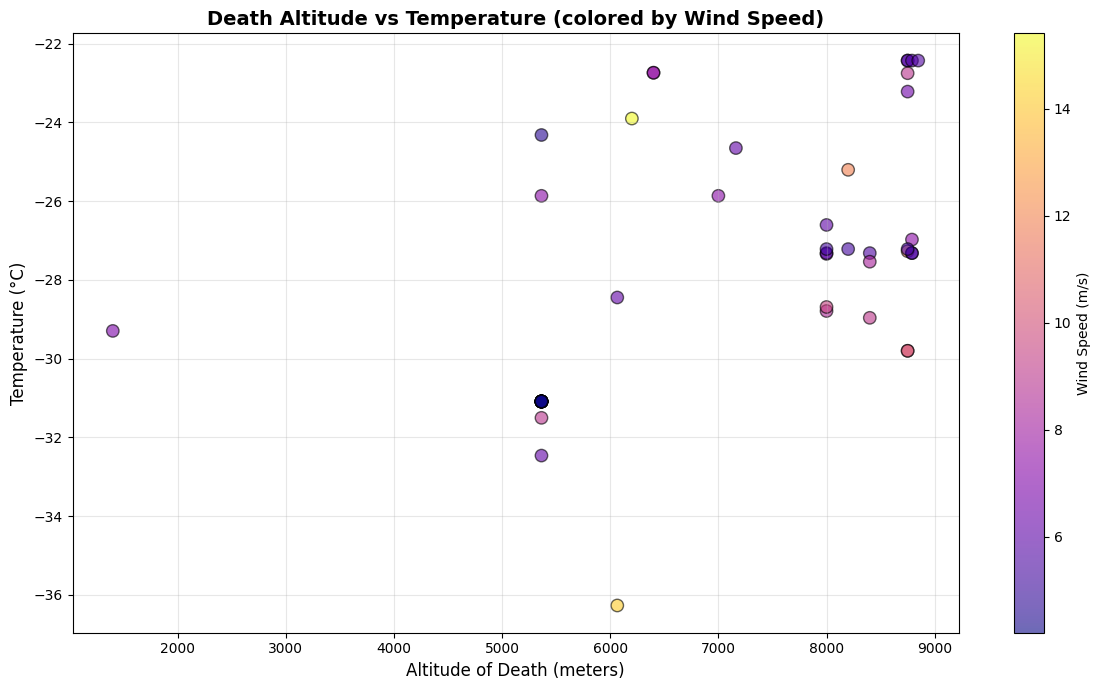

In [28]:
# 5. Altitude vs Temperature
plt.figure(figsize=(12, 7))
plt.scatter(everest_with_weather['Location_in_Meters'], 
           everest_with_weather['temperature_2m'],
           alpha=0.6,
           s=80,
           c=everest_with_weather['wind_speed_100m'],
           cmap='plasma',
           edgecolors='black')
plt.colorbar(label='Wind Speed (m/s)')
plt.xlabel('Altitude of Death (meters)', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.title('Death Altitude vs Temperature (colored by Wind Speed)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save plot
plt.savefig('images/everest_altitude_temp_wind.png', dpi=300, bbox_inches='tight')
plt.show()

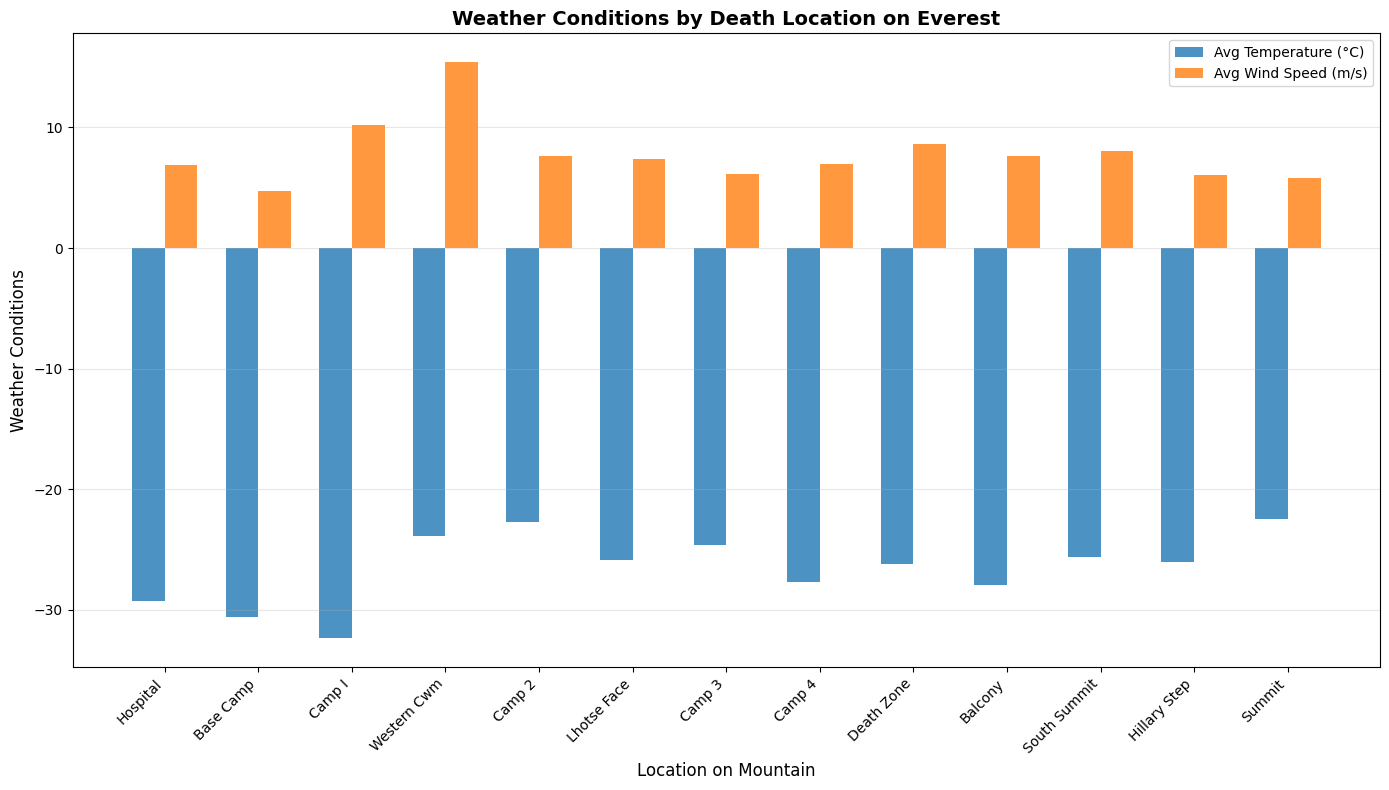

In [29]:
# Weather severity map by location
location_weather = everest_with_weather.groupby('Location').agg({
    'temperature_2m': 'mean',
    'wind_speed_100m': 'mean',
    'Location_in_Meters': 'mean'
}).sort_values('Location_in_Meters')

plt.figure(figsize=(14, 8))
x = range(len(location_weather))
width = 0.35

plt.bar([i - width/2 for i in x], location_weather['temperature_2m'], width, 
        label='Avg Temperature (°C)', alpha=0.8)
plt.bar([i + width/2 for i in x], location_weather['wind_speed_100m'], width,
        label='Avg Wind Speed (m/s)', alpha=0.8)

plt.xlabel('Location on Mountain', fontsize=12)
plt.ylabel('Weather Conditions', fontsize=12)
plt.title('Weather Conditions by Death Location on Everest', fontsize=14, fontweight='bold')
plt.xticks(x, location_weather.index, rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()

# Save plot
plt.savefig('images/everest_location_weather.png', dpi=300, bbox_inches='tight')
plt.show()

In [31]:
# 1. Deaths by Location Order (Ascending the Mountain) - Drop NaN altitudes
location_deaths = everest_with_weather.groupby('Location_Order').agg({
    'Location_Order': 'first',
    'Location': 'first',
    'Location_in_Meters': 'first'
}).reset_index(drop=True)

# Count deaths per location
death_counts = everest_with_weather.groupby('Location_Order').size().reset_index(name='deaths')
location_deaths = location_deaths.merge(death_counts, on='Location_Order')

# Drop rows with missing altitude data
location_deaths = location_deaths.dropna(subset=['Location_in_Meters'])

print("DEATHS BY LOCATION 2015-2022 (ASCENDING ORDER)")
print("=" * 80)
print(location_deaths.sort_values('Location_Order'))

DEATHS BY LOCATION 2015-2022 (ASCENDING ORDER)
    Location_Order      Location  Location_in_Meters  deaths
0              0.0      Hospital              1400.0       1
1              1.0     Base Camp              5364.0      19
2              3.0        Camp I              6065.0       2
3              4.0   Western Cwm              6200.0       1
4              5.0        Camp 2              6400.0       2
5              6.0   Lhotse Face              7000.0       1
6              7.0        Camp 3              7162.0       1
7             10.0        Camp 4              8000.0       6
8             11.0    Death Zone              8200.0       2
9             12.0       Balcony              8400.0       3
10            13.0  South Summit              8750.0       8
11            14.0  Hillary Step              8790.0       4
12            15.0        Summit              8848.0       1


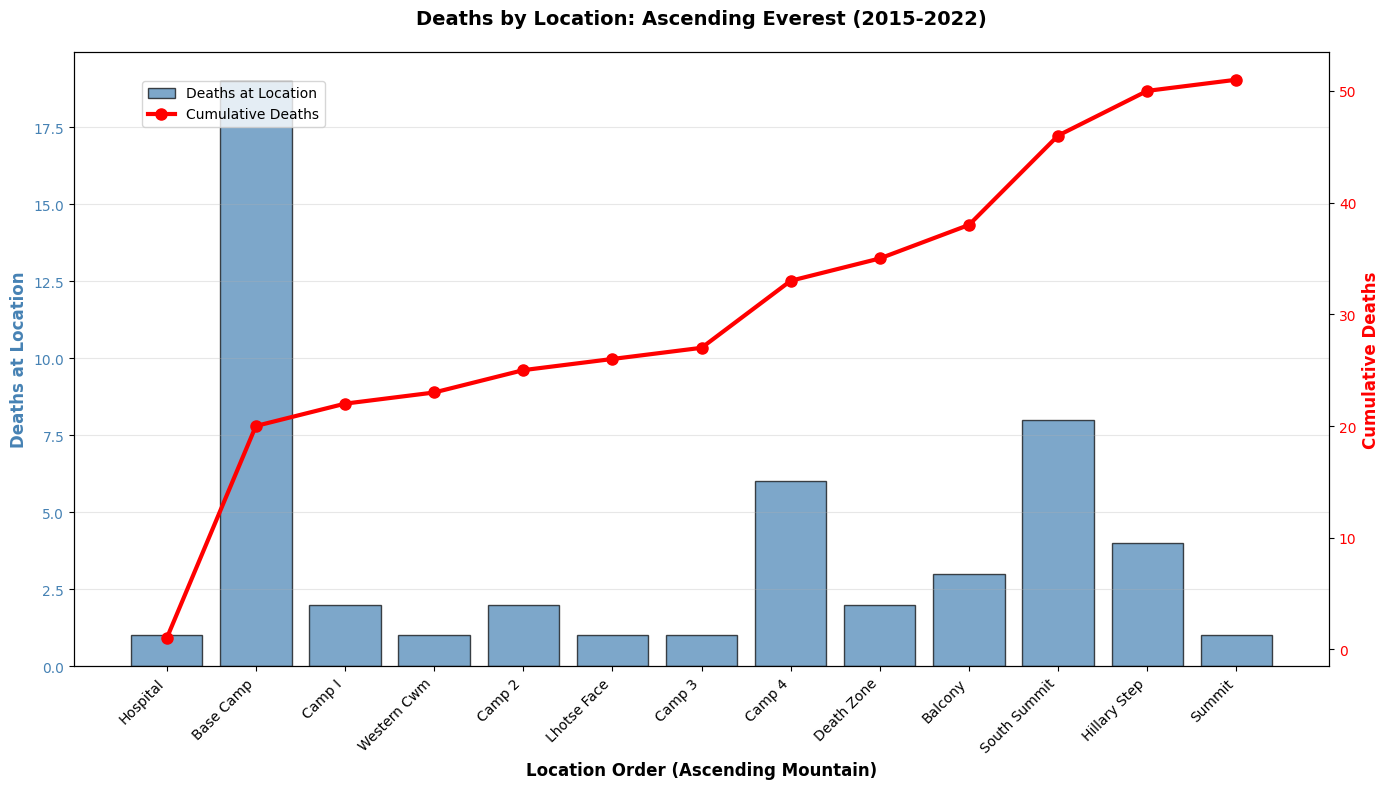

In [32]:
# 3. Cumulative Deaths as You Climb
location_deaths_sorted = location_deaths.sort_values('Location_Order')
location_deaths_sorted['cumulative_deaths'] = location_deaths_sorted['deaths'].cumsum()

fig, ax1 = plt.subplots(figsize=(14, 8))

# Bar chart of deaths at each location
ax1.bar(range(len(location_deaths_sorted)), 
        location_deaths_sorted['deaths'].values,
        color='steelblue',
        alpha=0.7,
        edgecolor='black',
        label='Deaths at Location')
ax1.set_xlabel('Location Order (Ascending Mountain)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Deaths at Location', fontsize=12, fontweight='bold', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# Line chart of cumulative deaths
ax2 = ax1.twinx()
ax2.plot(range(len(location_deaths_sorted)), 
         location_deaths_sorted['cumulative_deaths'].values,
         color='red',
         marker='o',
         linewidth=3,
         markersize=8,
         label='Cumulative Deaths')
ax2.set_ylabel('Cumulative Deaths', fontsize=12, fontweight='bold', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# X-axis labels with location names
ax1.set_xticks(range(len(location_deaths_sorted)))
ax1.set_xticklabels(location_deaths_sorted['Location'].values, rotation=45, ha='right')

plt.title('Deaths by Location: Ascending Everest (2015-2022)', 
          fontsize=14, fontweight='bold', pad=20)
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
ax1.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('images/everest_cumulative_deaths_climb.png', dpi=300, bbox_inches='tight')
plt.show()


Checking Location_in_Meters data:
        Location  Location_in_Meters
0         Camp I              6065.0
2     Death Zone              8200.0
3    Western Cwm              6200.0
4   South Summit              8750.0
6         Camp 4              8000.0
8      Base Camp              5364.0
9    Lhotse Face              7000.0
10       Balcony              8400.0
11  Hillary Step              8790.0
18        Camp 2              6400.0
20        Camp 3              7162.0
31        Summit              8848.0
35      Hospital              1400.0
51           NaN                 NaN

Data type: float64

Location deaths data:
    Location_Order      Location  Location_in_Meters  deaths
0              1.0     Base Camp              5364.0      19
1              3.0        Camp I              6065.0       2
2              4.0   Western Cwm              6200.0       1
3              5.0        Camp 2              6400.0       2
4              6.0   Lhotse Face              7000.0       1
5 

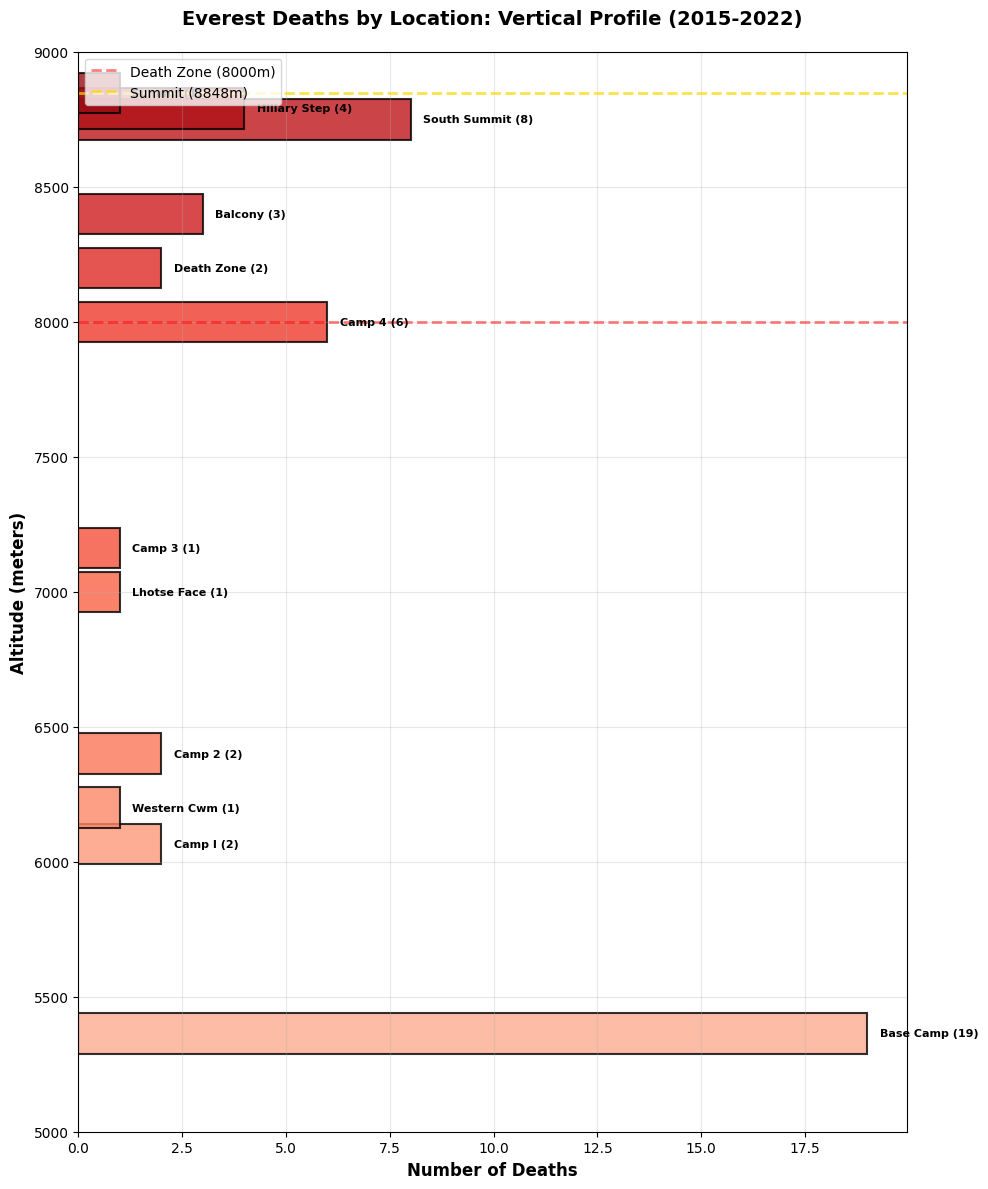


DEATHS BEFORE VS IN DEATH ZONE

Total deaths below Death Zone (<8000m): 27
Total deaths in Death Zone (≥8000m): 24
Percentage in Death Zone: 7.7%

--------------------------------------------------------------------------------
DEATHS BELOW DEATH ZONE (<8000m)
--------------------------------------------------------------------------------
Pavel Kostrikin                | Camp I                         | 6065m | Altitude sickness
Ngimi Tenji Sherpa             | Camp I                         | 6065m | Exhaustion
Pemba Tashi Sherpa             | Western Cwm                    | 6200m | Fall into crevasse
Dhruba Bista                   | Base Camp                      | 5364m | Altitude sickness
Kevin Hynes                    | Lhotse Face                    | 7000m | Altitude sickness
Chris Daly                     | Base Camp                      | 5364m | Fall
Damai Sarki Sherpa             | Camp 2                         | 6400m | Fall into crevasse
Nobukazu Kuriki                

In [40]:
# Check the data first
print("Checking Location_in_Meters data:")
print(everest_with_weather[['Location', 'Location_in_Meters']].drop_duplicates())
print(f"\nData type: {everest_with_weather['Location_in_Meters'].dtype}")

# Remove 'm' and convert to numeric
everest_with_weather['Location_in_Meters'] = everest_with_weather['Location_in_Meters'].astype(str).str.replace('m', '').str.strip()
everest_with_weather['Location_in_Meters'] = pd.to_numeric(everest_with_weather['Location_in_Meters'], errors='coerce')

# Now recreate location_deaths with proper numeric altitudes
location_deaths = everest_with_weather.groupby('Location_Order').agg({
    'Location': 'first',
    'Location_in_Meters': 'first'
}).reset_index()

# Count deaths per location
death_counts = everest_with_weather.groupby('Location_Order').size().reset_index(name='deaths')
location_deaths = location_deaths.merge(death_counts, on='Location_Order')

# Drop rows with missing altitude data
location_deaths = location_deaths.dropna(subset=['Location_in_Meters'])
# Remove hospital records
location_deaths = location_deaths[location_deaths['Location'] != 'Hospital']

# Reset index so it matches color array indexing
location_deaths = location_deaths.reset_index(drop=True)

print("\nLocation deaths data:")
print(location_deaths.sort_values('Location_in_Meters'))

# 2. Vertical Profile Visualization
fig, ax = plt.subplots(figsize=(10, 12))

# Create vertical bars at each location
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(location_deaths)))

for idx, row in location_deaths.iterrows():
    altitude = float(row['Location_in_Meters'])  # Ensure it's a float
    
    # Horizontal bar showing deaths at this altitude
    ax.barh(altitude, row['deaths'], 
            height=150,  # Bar height (altitude range)
            left=0,
            color=colors[idx],
            edgecolor='black',
            linewidth=1.5,
            alpha=0.8)
    
    # Label with location name and death count
    ax.text(row['deaths'] + 0.3, altitude, 
            f"{row['Location']} ({row['deaths']})",
            va='center',
            fontsize=8,
            fontweight='bold')

# Add reference lines
ax.axhline(8000, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Death Zone (8000m)')
ax.axhline(8849, color='gold', linestyle='--', linewidth=2, alpha=0.7, label='Summit (8848m)')

# Set y-axis limits to show full mountain range
ax.set_ylim(5000, 9000)

ax.set_xlabel('Number of Deaths', fontsize=12, fontweight='bold')
ax.set_ylabel('Altitude (meters)', fontsize=12, fontweight='bold')
ax.set_title('Everest Deaths by Location: Vertical Profile (2015-2022)', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()

# Save plot
plt.savefig('images/everest_death_vertical_profile.png', dpi=300, bbox_inches='tight')
plt.show()

# After the plot, add this analysis:

print("\n" + "=" * 80)
print("DEATHS BEFORE VS IN DEATH ZONE")
print("=" * 80)

# Split deaths by Death Zone (8000m)
below_death_zone = everest_with_weather[everest_with_weather['Location_in_Meters'] < 8000]
in_death_zone = everest_with_weather[everest_with_weather['Location_in_Meters'] >= 8000]

print(f"\nTotal deaths below Death Zone (<8000m): {len(below_death_zone)}")
print(f"Total deaths in Death Zone (≥8000m): {len(in_death_zone)}")
print(f"Percentage in Death Zone: {len(in_death_zone)/len(everest_with_weather)*100:.1f}%")

print("\n" + "-" * 80)
print("DEATHS BELOW DEATH ZONE (<8000m)")
print("-" * 80)
for idx, row in below_death_zone.iterrows():
    print(f"{row['Name']:30s} | {row['Location']:30s} | {row['Location_in_Meters']:.0f}m | {row['Cause of death']}")

print("\n" + "-" * 80)
print("DEATHS IN DEATH ZONE (≥8000m)")
print("-" * 80)
for idx, row in in_death_zone.iterrows():
    print(f"{row['Name']:30s} | {row['Location']:30s} | {row['Location_in_Meters']:.0f}m | {row['Cause of death']}")

# Summary by location
print("\n" + "=" * 80)
print("SUMMARY BY LOCATION")
print("=" * 80)

print("\nBELOW DEATH ZONE:")
below_summary = below_death_zone.groupby('Location').agg({
    'Name': 'count',
    'Location_in_Meters': 'first'
}).rename(columns={'Name': 'Deaths'}).sort_values('Location_in_Meters')
print(below_summary)

print("\nIN DEATH ZONE:")
in_summary = in_death_zone.groupby('Location').agg({
    'Name': 'count',
    'Location_in_Meters': 'first'
}).rename(columns={'Name': 'Deaths'}).sort_values('Location_in_Meters')
print(in_summary)